# ETAPA 2: Análisis exploratorio y perfilado
# Objetivo: Explorar la evolución de los datos y realizar análisis comparativos.
# Rango temporal: 6 meses de datos (enero–junio 2020).
## Dificultad: Media – combinar múltiples archivos y realizar cálculos agregados. bold text

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display
import datetime

import requests

%pylab inline
import seaborn as sb
# pd.set_option('display.precision', 5)

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
# Define the start and end dates (6 primeros meses del 2021)
start_date = '2021-01-01'
end_date = '2021-6-30'

date_range = pd.date_range(start=start_date, end=end_date)

# print(date_range)

df = []

In [3]:
# Importar Enero 2021 #2.2

for single_date in date_range:
    url = f'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/refs/heads/master/csse_covid_19_data/csse_covid_19_daily_reports/{single_date.strftime("%m-%d-%Y")}.csv'
    df.append(pd.read_csv(url))

In [4]:
# Concadencacion
seisMeses = pd.concat(df, ignore_index=True)

In [5]:
print("antes de optimizar")
seisMeses.info(memory_usage='deep')

antes de optimizar
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 726498 entries, 0 to 726497
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   FIPS                 591132 non-null  float64
 1   Admin2               592037 non-null  object 
 2   Province_State       694119 non-null  object 
 3   Country_Region       726498 non-null  object 
 4   Last_Update          726498 non-null  object 
 5   Lat                  710222 non-null  float64
 6   Long_                710222 non-null  float64
 7   Confirmed            726498 non-null  int64  
 8   Deaths               726498 non-null  int64  
 9   Recovered            346418 non-null  float64
 10  Active               346418 non-null  float64
 11  Combined_Key         726498 non-null  object 
 12  Incident_Rate        710222 non-null  float64
 13  Case_Fatality_Ratio  718104 non-null  float64
dtypes: float64(7), int64(2), object(5)
memory usage: 

In [6]:
try:
    # Columnas de texto repetitivo -> 'category' (mayor ahorro de memoria)
    seisMeses['Country_Region'] = seisMeses['Country_Region'].astype('category')
    seisMeses['Province_State'] = seisMeses['Province_State'].astype('category')
    seisMeses['Admin2'] = seisMeses['Admin2'].astype('category')

    # Columnas numéricas (Rellenamos NaN con 0 y convertimos a entero de 32 bits)
    seisMeses['Confirmed'] = pd.to_numeric(seisMeses['Confirmed'], errors='coerce').fillna(0).astype('int32')
    seisMeses['Deaths'] = pd.to_numeric(seisMeses['Deaths'], errors='coerce').fillna(0).astype('int32')

    # Columnas con decimales o que pueden tener NaN (Convertimos a float de 32 bits)
    seisMeses['Recovered'] = pd.to_numeric(seisMeses['Recovered'], errors='coerce').astype('float32')
    seisMeses['Active'] = pd.to_numeric(seisMeses['Active'], errors='coerce').astype('float32')
    seisMeses['Lat'] = pd.to_numeric(seisMeses['Lat'], errors='coerce').astype('float32')
    seisMeses['Long_'] = pd.to_numeric(seisMeses['Long_'], errors='coerce').astype('float32')

    # Fechas
    seisMeses['Last_Update'] = pd.to_datetime(seisMeses['Last_Update'], errors='coerce')
    
    print("\n¡Optimización completa!")

except KeyError as e:
    print(f"Error: La columna {e} no se encontró. Es posible que el DataFrame esté vacío o los nombres de columna hayan cambiado.")
except Exception as e:
    print(f"Ocurrió un error inesperado durante la conversión: {e}")



¡Optimización completa!


In [7]:
print("despues de optimizar")
seisMeses.info(memory_usage='deep')

despues de optimizar
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 726498 entries, 0 to 726497
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   FIPS                 591132 non-null  float64       
 1   Admin2               592037 non-null  category      
 2   Province_State       694119 non-null  category      
 3   Country_Region       726498 non-null  category      
 4   Last_Update          726461 non-null  datetime64[ns]
 5   Lat                  710222 non-null  float32       
 6   Long_                710222 non-null  float32       
 7   Confirmed            726498 non-null  int32         
 8   Deaths               726498 non-null  int32         
 9   Recovered            346418 non-null  float32       
 10  Active               346418 non-null  float32       
 11  Combined_Key         726498 non-null  object        
 12  Incident_Rate        710222 non-null  float64      

1. ¿Cuáles son los 10 países con más casos confirmados acumulados durante el semestre?

In [8]:
totalPaisConfirmados = seisMeses.groupby('Country_Region')['Confirmed'].sum().sort_values(ascending=False)
top10 = totalPaisConfirmados.head(10)
print('Top 10 países con más casos confirmados acumulados al 2020-06-30:')
display(top10.reset_index().rename(columns={'6/30/20':'Confirmado acumulado'}))

Top 10 países con más casos confirmados acumulados al 2020-06-30:


/tmp/ipykernel_79179/3289889651.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  totalPaisConfirmados = seisMeses.groupby('Country_Region')['Confirmed'].sum().sort_values(ascending=False)


,Country_Region,Confirmed
0,US,5412065912
1,India,3085844316
2,Brazil,2326197586
3,France,831568058
4,Russia,802529033
5,United Kingdom,757138369
6,Turkey,678964897
7,Italy,621181216
8,Spain,582139639
9,Germany,523778221


2. ¿Qué países presentan mayor tasa de letalidad (Deaths / Confirmed * 100)?

In [9]:
%%time
totalPaisMuertes = seisMeses.groupby('Country_Region')['Deaths'].sum().sort_values(ascending=False)
totalPaisMuertes

CPU times: user 5.59 ms, sys: 2.12 ms, total: 7.72 ms
Wall time: 12.9 ms


<timed exec>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


Country_Region
US                      95217344
Brazil                  61314911
India                   39136935
Mexico                  35350954
United Kingdom          26218837
                          ...   
Samoa                          0
Tonga                          0
Summer Olympics 2020           0
Tuvalu                         0
Winter Olympics 2022           0
Name: Deaths, Length: 201, dtype: int32

In [10]:
%%time
tabla_letalidad = pd.merge(totalPaisConfirmados,totalPaisMuertes, on='Country_Region',how='outer')
tabla_letalidad['tasa_letalidad'] = tabla_letalidad['Confirmed'] / tabla_letalidad['Deaths']
tabla_letalidad
tabla_letalidad = tabla_letalidad.rename(columns={'Confirmed': "Confirmados", 'Deaths': "Muertes"})
tabla_letalidad.sort_values(by='tasa_letalidad', ascending=True)

CPU times: user 3.9 ms, sys: 1.99 ms, total: 5.89 ms
Wall time: 6.31 ms


,Confirmados,Muertes,tasa_letalidad
Country_Region,,,
MS Zaandam,1629,362,4.500000
Yemen,798884,171685,4.653196
Vanuatu,482,71,6.788732
Peru,280726440,26112846,10.750511
Mexico,390216776,35350954,11.038366
...,...,...,...
Nauru,0,0,NaN
Palau,0,0,NaN
Tonga,0,0,NaN


3. ¿Cuántos países no registran recuperados en los datos analizados?

In [11]:
%%time
#Revisar bien porque cuenta todos los 0, no solo los del recuperado, es una serie
totalRecuperadosPais = seisMeses.groupby('Country_Region')['Recovered'].sum()
NoRecuperados = (totalRecuperadosPais == 0).sum()
print('En total hay ',NoRecuperados,' paises que no registran recuperados en esos 6 meses')

En total hay  13  paises que no registran recuperados en esos 6 meses
CPU times: user 6.69 ms, sys: 744 μs, total: 7.43 ms
Wall time: 17.8 ms


<timed exec>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


4. ¿Qué país latinoamericano presenta la mayor cantidad de casos activos en junio 2020?

In [12]:
%%time
tablaActivos = pd.merge(tabla_letalidad,totalRecuperadosPais, on='Country_Region',how='outer')
tablaActivos = tablaActivos.rename(columns={'Recovered': "Recuperados"})
tablaActivos['Activos'] = (tablaActivos['Confirmados'] - tablaActivos['Muertes'] - tablaActivos['Recuperados']).clip(lower=0)
mayorActivos = tablaActivos['Activos'].idxmax()
print('El pais latinoamericano con la mayor cantidad de casos activos en junio del 2020 es',mayorActivos)

El pais latinoamericano con la mayor cantidad de casos activos en junio del 2020 es US
CPU times: user 3.72 ms, sys: 0 ns, total: 3.72 ms
Wall time: 3.59 ms


5. ¿Cómo evolucionaron los casos confirmados en Chile entre enero y junio? (gráfico de
líneas).

CPU times: user 89.9 ms, sys: 5.72 ms, total: 95.6 ms
Wall time: 156 ms


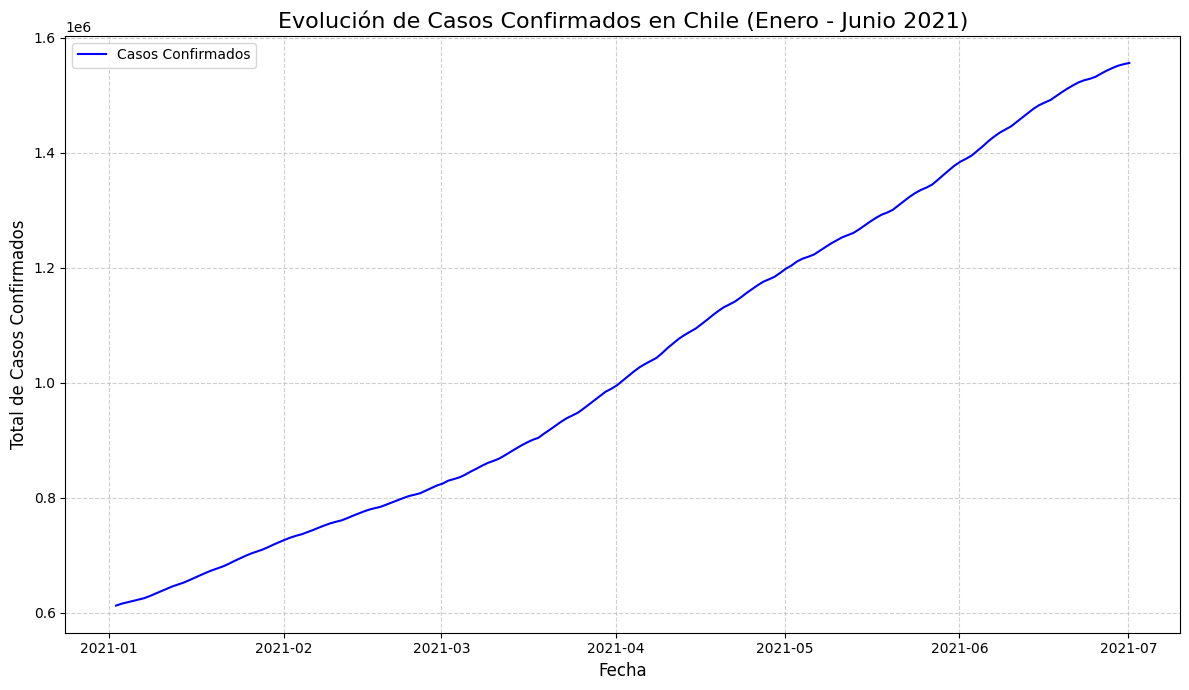

In [13]:
%%time
datosChile = seisMeses.loc[seisMeses['Country_Region'] == 'Chile'].copy()
datosChile['Last_Update'] = pd.to_datetime(datosChile['Last_Update'])
datosAgrupados = datosChile.groupby(datosChile['Last_Update'])['Confirmed'].sum().reset_index()
datosAgrupados

plt.figure(figsize=(12, 7))
plt.plot(datosAgrupados['Last_Update'], datosAgrupados['Confirmed'], label='Casos Confirmados', color='b')

plt.title('Evolución de Casos Confirmados en Chile (Enero - Junio 2021)', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Total de Casos Confirmados', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()


6. ¿Cuál fue la fecha con más nuevos casos a nivel mundial durante este período?

In [14]:
%%time
casosNuevos = seisMeses[['Country_Region','Last_Update','Confirmed']].copy()
casosNuevos['Last_Update'] = pd.to_datetime(casosNuevos['Last_Update'], format='ISO8601')

casosNuevos['Last_Update'] = casosNuevos['Last_Update'].dt.date

casosNuevos_mundial = casosNuevos.groupby('Last_Update')['Confirmed'].sum().reset_index()
casosNuevos_mundial['Nuevos Casos'] = casosNuevos_mundial['Confirmed'].diff()

fila_max_nuevos = casosNuevos_mundial.loc[casosNuevos_mundial['Nuevos Casos'].idxmax()]

fecha_max = fila_max_nuevos['Last_Update']
casos_max = fila_max_nuevos['Nuevos Casos']

print(f"\nLa fecha con más nuevos casos reportados a nivel mundial fue: {fecha_max}, con un total de {int(casos_max):,} casos nuevos")


La fecha con más nuevos casos reportados a nivel mundial fue: 2021-01-02, con un total de 84,323,180 casos nuevos
CPU times: user 222 ms, sys: 10.6 ms, total: 232 ms
Wall time: 237 ms


7. ¿Existe correlación entre casos confirmados y fallecidos? (gráfico de dispersión +
regresión).

In [15]:
%%time
cols_to_plot = ['Confirmed', 'Deaths']
seisMeses_paises = seisMeses.copy()

CPU times: user 13.6 ms, sys: 14 ms, total: 27.7 ms
Wall time: 26.6 ms


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

CPU times: user 633 ms, sys: 17.8 ms, total: 650 ms
Wall time: 693 ms


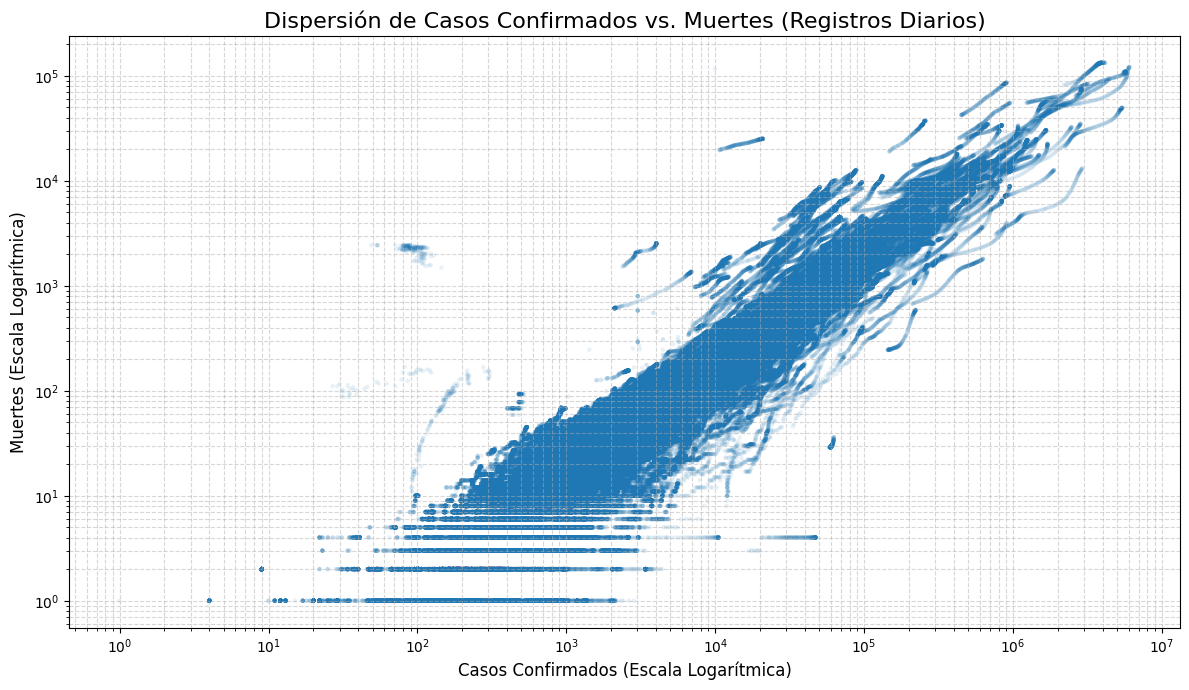

In [16]:
%%time
plt.figure(figsize=(12, 7))

# Usamos sns.scatterplot (en lugar de regplot)
# 'alpha=0.1' hace los puntos 90% transparentes para ver la densidad
# 's=10' hace los puntos más pequeños
sb.scatterplot(
    data=seisMeses_paises, 
    x='Confirmed', 
    y='Deaths',
    alpha=0.1, 
    s=10,
    edgecolor='none' # Quitar bordes de los puntos
)

# ¡¡Crucial!! Usar escala logarítmica para que los datos se separen
plt.xscale('log')
plt.yscale('log')

plt.title('Dispersión de Casos Confirmados vs. Muertes (Registros Diarios)', fontsize=16)
plt.xlabel('Casos Confirmados (Escala Logarítmica)', fontsize=12)
plt.ylabel('Muertes (Escala Logarítmica)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5, which='both') 
plt.tight_layout()

Gráfico guardado exitosamente como: grafico_regresion_por_pais.png
CPU times: user 1min 25s, sys: 623 ms, total: 1min 26s
Wall time: 1min 4s


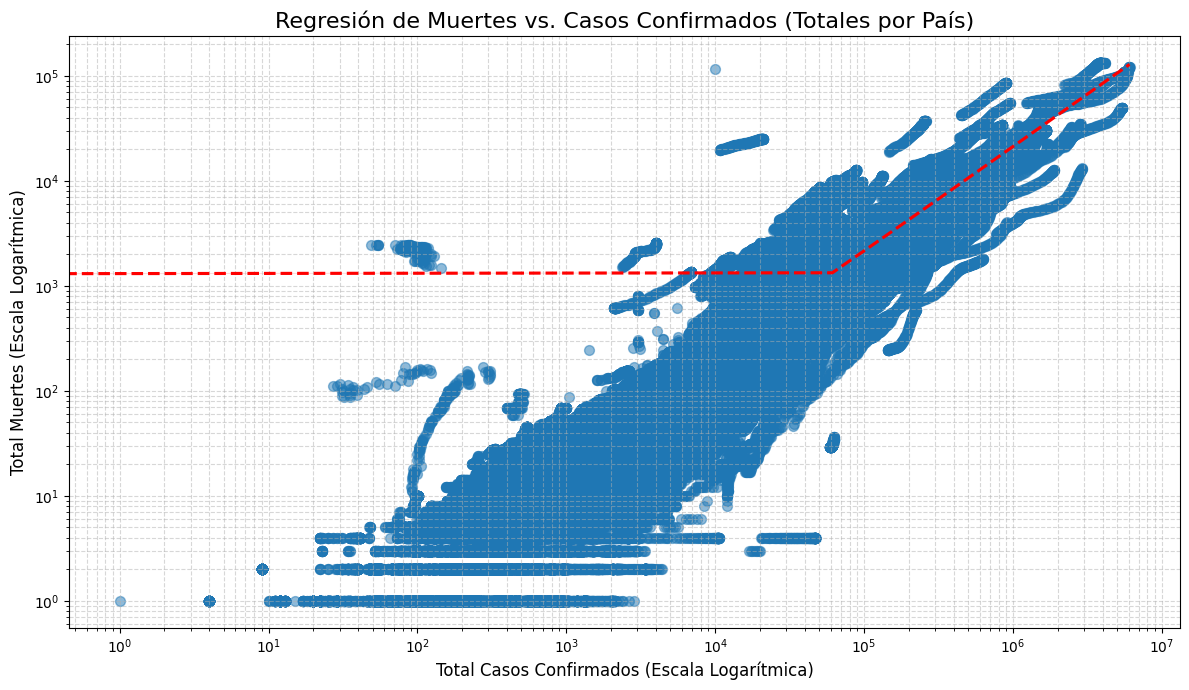

In [17]:
%%time
plt.figure(figsize=(12, 7))

# sns.regplot() dibuja los puntos Y la línea de regresión
sb.regplot(
    data=seisMeses_paises, 
    x='Confirmed', 
    y='Deaths',
    scatter_kws={'alpha': 0.5, 's': 50},       # Estilo de los puntos
    line_kws={'color': 'red', 'linestyle': '--'} # Estilo de la línea
)

# ¡¡Crucial!! Usar escala logarítmica en ambos ejes
plt.xscale('log')
plt.yscale('log')

plt.title('Regresión de Muertes vs. Casos Confirmados (Totales por País)', fontsize=16)
plt.xlabel('Total Casos Confirmados (Escala Logarítmica)', fontsize=12)
plt.ylabel('Total Muertes (Escala Logarítmica)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5, which='both')
plt.tight_layout()

# Guardar el Gráfico
output_filename = 'grafico_regresion_por_pais.png'
plt.savefig(output_filename)
print(f"Gráfico guardado exitosamente como: {output_filename}")

8. Mostrar el Top 10 de países con mayor crecimiento porcentual de casos entre mayo y
junio.

In [18]:
%%time
mayorCrecimiento = seisMeses.copy()
mayorCrecimiento['Last_Update'] = pd.to_datetime(mayorCrecimiento['Last_Update'], format='ISO8601')
crecimientoDaily = mayorCrecimiento.groupby(['Country_Region', 'Last_Update'])['Confirmed'].sum().reset_index()

fecha_mayo = pd.to_datetime('2021-05-31')
fecha_junio = pd.to_datetime('2021-06-30')

#Crecimiento historico finales de mayo.
df_mayo_historico = crecimientoDaily[crecimientoDaily['Last_Update'] <= fecha_mayo]
df_mayo_final = df_mayo_historico.groupby('Country_Region')['Confirmed'].max().reset_index()
df_mayo_final.columns = ['Country_Region', 'Total_Mayo']

#crecimiento historico finales de junio
df_junio_historico = crecimientoDaily[crecimientoDaily['Last_Update'] <= fecha_junio]
df_junio_final = df_junio_historico.groupby('Country_Region')['Confirmed'].max().reset_index()
df_junio_final.columns = ['Country_Region', 'Total_Junio']

crecimientoTotal = pd.merge(df_mayo_final, df_junio_final, on='Country_Region', how='inner')
threshold = 100
df_growth_filtrado = crecimientoTotal[crecimientoTotal['Total_Mayo'] > threshold]

df_growth_filtrado['Crecimiento_Porc'] = ((df_growth_filtrado['Total_Junio'] - df_growth_filtrado['Total_Mayo']) / df_growth_filtrado['Total_Mayo']) * 100
df_top10 = df_growth_filtrado.sort_values(by='Crecimiento_Porc', ascending=False).head(10)
df_top10


CPU times: user 72.3 ms, sys: 45.9 ms, total: 118 ms
Wall time: 200 ms


<timed exec>:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<timed exec>:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<timed exec>:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<timed exec>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/

,Country_Region,Total_Mayo,Total_Junio,Crecimiento_Porc
61,Fiji,360,3832,964.444444
195,Vietnam,6908,16136,133.584250
121,Mongolia,56621,111505,96.932234
175,Taiwan*,7806,14694,88.239816
187,Uganda,45931,79089,72.190895
102,Liberia,2179,3736,71.454796
31,Cambodia,28825,48532,68.367736
178,Thailand,149779,249853,66.814440
0,Afghanistan,70111,115751,65.096775
125,Namibia,54659,86649,58.526501


9. Identificar países con rebrote (un día sin casos y luego un incremento posterior).

In [19]:
%%time
rebrote = seisMeses.copy()
rebrote['Last_Update'] = pd.to_datetime(rebrote['Last_Update'], format='ISO8601')

rebrote = rebrote.sort_values(by=['Country_Region', 'Last_Update'])
rebrote['Nuevos_Casos'] = rebrote.groupby('Country_Region')['Confirmed'].diff()

rebrote['Nuevos_Casos'] = rebrote['Nuevos_Casos'].fillna(rebrote['Confirmed'])
rebrote['Nuevos_Casos'] = rebrote['Nuevos_Casos'].clip(lower=0)

CPU times: user 103 ms, sys: 44 ms, total: 147 ms
Wall time: 259 ms


<timed exec>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


In [20]:
%%time
paises_con_rebrote = []
# Asumiendo que 'rebrote' ya está cargado y procesado de la celda anterior (09439694)
datos_agrupados = rebrote.groupby('Country_Region')

for nombre_pais, datos_pais in datos_agrupados:
    
    # Obtener todas las fechas donde hubo 0 casos nuevos
    fechas_cero_casos = datos_pais[datos_pais['Nuevos_Casos'] == 0]['Last_Update']
    
    # Si nunca tuvo un día con 0 casos, no puede tener rebrote
    if fechas_cero_casos.empty:
        continue
        
    # Encontrar la PRIMERA fecha con 0 casos
    primera_fecha_cero = fechas_cero_casos.min()
    
    # --- CÓDIGO CORREGIDO ---
    # Filtramos los datos para ver si hay algún día POSTERIOR con casos
    df_filtrado = datos_pais[
        (datos_pais['Last_Update'] > primera_fecha_cero) & 
        (datos_pais['Nuevos_Casos'] > 0)
    ]
    
    # Comprobamos si el DataFrame filtrado NO está vacío
    # Esto es más claro que .any().any() y elimina la advertencia.
    tiene_crecimiento_posterior = not df_filtrado.empty
    # --- FIN DE LA CORRECCIÓN ---
    
    if tiene_crecimiento_posterior:
        paises_con_rebrote.append(nombre_pais)

# --- 5. Mostrar Resultados ---
print("\n--- Países Identificados con Rebrote ---")
if paises_con_rebrote:
    for pais in paises_con_rebrote:
        print(f"- {pais}")
else:
    print("No se encontraron países con el patrón de rebrote especificado.")

<timed exec>:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



--- Países Identificados con Rebrote ---
- Afghanistan
- Albania
- Algeria
- Andorra
- Antigua and Barbuda
- Australia
- Bahamas
- Barbados
- Belgium
- Belize
- Benin
- Bhutan
- Bolivia
- Bosnia and Herzegovina
- Botswana
- Brazil
- Brunei
- Bulgaria
- Burkina Faso
- Burma
- Burundi
- Cabo Verde
- Cambodia
- Cameroon
- Canada
- Central African Republic
- Chad
- Chile
- China
- Colombia
- Comoros
- Congo (Brazzaville)
- Congo (Kinshasa)
- Costa Rica
- Cote d'Ivoire
- Czechia
- Denmark
- Djibouti
- Dominica
- El Salvador
- Equatorial Guinea
- Eritrea
- Eswatini
- Fiji
- France
- Gabon
- Gambia
- Germany
- Ghana
- Greece
- Grenada
- Guatemala
- Guinea
- Guinea-Bissau
- Guyana
- Haiti
- Honduras
- Hungary
- Iceland
- India
- Israel
- Italy
- Japan
- Jordan
- Kazakhstan
- Kiribati
- Kosovo
- Kyrgyzstan
- Laos
- Lebanon
- Lesotho
- Liberia
- Libya
- Liechtenstein
- Luxembourg
- Madagascar
- Malawi
- Malaysia
- Mali
- Malta
- Mauritania
- Mauritius
- Mexico
- Monaco
- Mozambique
- Namibia
- 

10. Generar un reporte de perfilado automático (ydata-profiling o pandas_profiling) que incluya
distribuciones, correlaciones y resumen de calidad de datos.

In [ ]:
%%time
from ydata_profiling import ProfileReport


# Crea el objeto de reporte
profile = ProfileReport(seisMeses, title="Reporte de Perfilado - Datos COVID")


# --- 3. Guardar el Reporte como HTML ---
output_filename = "perfilado_covid.html"
profile.to_file(output_filename)

print(f"\n--- ¡Reporte Generado! ---")
print(f"Abre este archivo en tu navegador: {output_filename}")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:05<00:00,  2.66it/s]
/usr/local/python/3.12.1/lib/python3.12/site-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(
/usr/local/python/3.12.1/lib/python3.12/site-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(
/home/codespace/.local/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defin

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]


--- ¡Reporte Generado! ---
Abre este archivo en tu navegador: reporte_perfilado_covid.html
CPU times: user 30 s, sys: 3.91 s, total: 34 s
Wall time: 45.3 s
